# Regularization

**Why We Intentionally Make a Model “Worse” on Training Data**

## Introduction

In machine learning and statistics, one of the central goals is not merely to fit the observed data, but to **generalize** well to unseen data. This distinction is crucial. A model that performs extremely well on the training set may still fail badly when applied to new observations. This phenomenon is known as **overfitting（过拟合）**.

**Regularization（正则化）** is one of the most important ideas developed to address this problem. At its core, regularization modifies the learning process so that the model is discouraged from becoming unnecessarily complex. The surprising but fundamental idea is this:

```quote
A model can sometimes achieve better test performance by being forced to fit the training data a little less aggressively.
```

This tutorial gives a complete, textbook-style introduction to regularization. We begin with intuition, then move to formal definitions, then study the most important methods—**Ridge（岭回归）**, **Lasso（套索回归）**, and **Elastic Net（弹性网络**）—and finally connect regularization to the Bayesian idea of a **prior（先验）**. A small Python example is included near the end.

## The Core Problem: Why Fitting the Training Data Is Not Enough

Suppose we are building a model to predict house prices from variables such as:

- square footage
- number of bedrooms
- age of the house
- school rating
- distance to downtown

If our model is too simple, it may miss important patterns. This is called **underfitting（欠拟合）**. But if the model is too flexible, it may begin to fit not only the true signal, but also random noise in the training data. This is **overfitting（过拟合）**.

A useful way to think about this is through curve fitting. Imagine a scatterplot:

- A straight line may be too rigid.
- A highly wiggly polynomial may pass through nearly every point.

The second model may have very small training error, but it often captures accidental fluctuations rather than stable structure. When new data arrive, its performance deteriorates.

Regularization is designed to reduce this tendency.

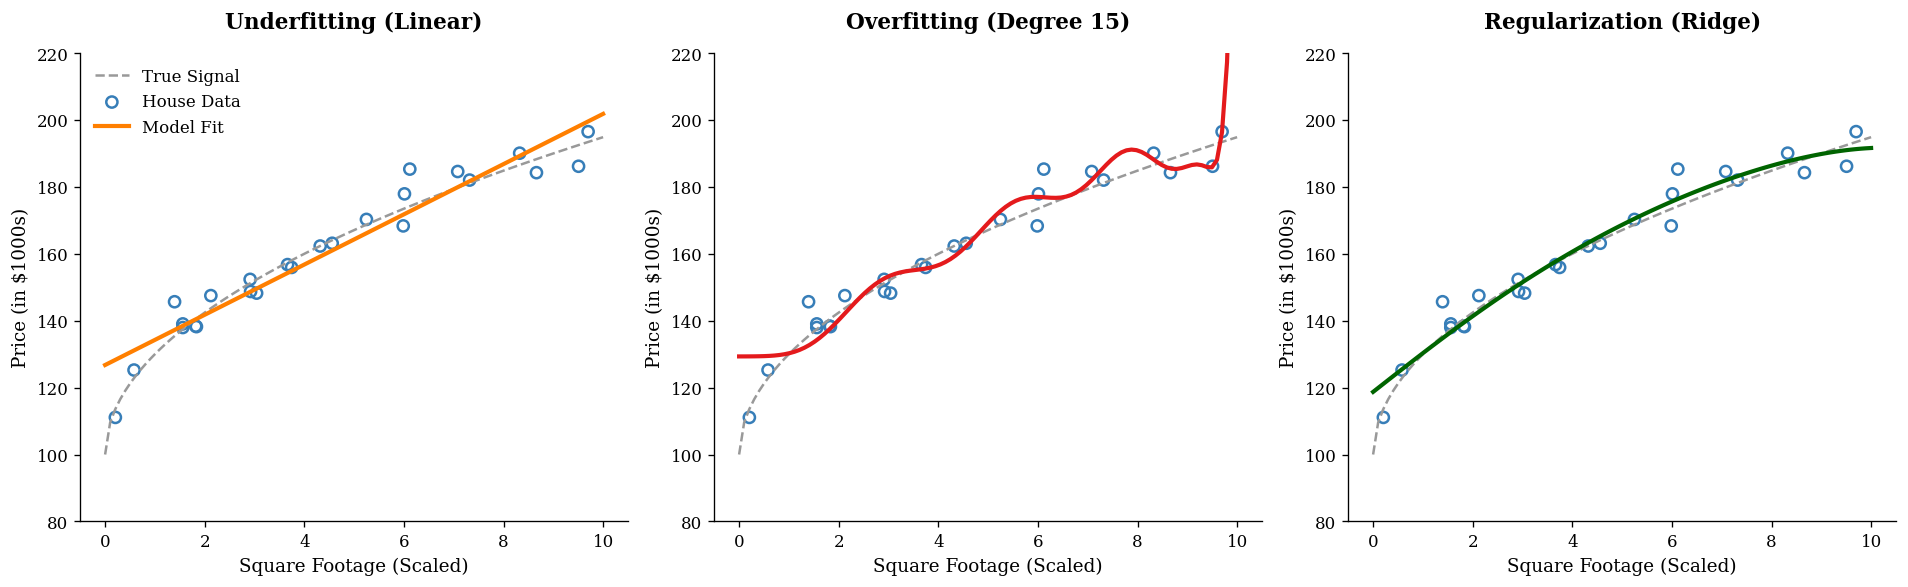

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge

# --- 全局风格配置 (修正版) ---
plt.rcParams.update({
    "font.family": "serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 11,
    "axes.titleweight": 'bold',  # 修正后的键名
    "axes.titlesize": 13
})

# ISL 经典配色
ISL_BLUE = '#377eb8'   # 训练数据与稳健拟合
ISL_RED = '#e41a1c'    # 过拟合表现
ISL_ORANGE = '#ff7f00' # 欠拟合表现
ISL_GRAY = '#999999'   # 真实规律

# 1. 生成模拟房价数据 (x: 房屋面积, y: 价格)
np.random.seed(42)
n_samples = 25
X = np.sort(np.random.rand(n_samples) * 10)
y_true = 100 + 30 * np.sqrt(X) 
y = y_true + np.random.normal(0, 4, size=n_samples) 

X_plot = np.linspace(0, 10, 100)

# 2. 拟合三种场景模型
# 欠拟合：线性回归
model_under = make_pipeline(PolynomialFeatures(1), LinearRegression())
# 过拟合：超高阶多项式（不带正则化）
model_over = make_pipeline(PolynomialFeatures(15), LinearRegression())
# 理想状态：正则化回归 (Ridge)
model_ridge = make_pipeline(PolynomialFeatures(5), Ridge(alpha=0.5))

# 3. 开始绘图
fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=120)

titles = ["Underfitting (Linear)", "Overfitting (Degree 15)", "Regularization (Ridge)"]
models = [model_under, model_over, model_ridge]
colors = [ISL_ORANGE, ISL_RED, 'darkgreen']

for ax, model, title, color in zip(axes, models, titles, colors):
    model.fit(X.reshape(-1, 1), y)
    y_plot = model.predict(X_plot.reshape(-1, 1))
    
    # 绘制真实规律（Ground Truth）
    ax.plot(X_plot, 100 + 30 * np.sqrt(X_plot), color=ISL_GRAY, linestyle='--', lw=1.5, label='True Signal')
    
    # 绘制观测点
    ax.scatter(X, y, facecolors='none', edgecolors=ISL_BLUE, s=45, lw=1.5, label='House Data')
    
    # 绘制模型拟合线
    ax.plot(X_plot, y_plot, color=color, linewidth=2.5, label='Model Fit')
    
    ax.set_title(title, pad=15)
    ax.set_xlabel("Square Footage (Scaled)")
    ax.set_ylabel("Price (in $1000s)")
    ax.set_ylim(80, 220)
    
    if title == "Underfitting (Linear)":
        ax.legend(frameon=False)

plt.tight_layout()
plt.show()

## The Big Idea of Regularization

Before regularization, many learning problems can be written as:

$$\min_{\theta} \text{Loss}(\theta)$$

where $\theta$ denotes the model parameters.

With regularization, we instead solve:

$$\min_{\theta} \text{Loss}(\theta) + \lambda \Omega(\theta)$$

This expression contains the entire philosophy of regularization.

## The loss term

The **loss function (损失函数)** measures how well the model fits the observed data.

For example, in linear regression, a common loss is the **residual sum of squares (残差平方和, RSS)**:

$$\text{RSS}(\beta) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

### The penalty term

The function $\Omega(\theta)$ is the **penalty (惩罚项)**. It measures model complexity, usually through the size of the coefficients.

### The tuning parameter

The constant $\lambda \geq 0$ controls how strongly complexity is penalized.

* If $\lambda = 0$, there is no regularization.
* If $\lambda$ is small, the penalty is mild.
* If $\lambda$ is large, the model is heavily constrained.

So regularization asks the model to do two things at once:

1.  **fit the data well**
2.  **avoid becoming too complex**

This trade-off is the essence of the method.

---

## Why Penalize Large Coefficients?

Consider a linear model:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p$$

Why would large coefficients be a sign of complexity?

If a coefficient $\beta_j$ is large in magnitude, then a small change in $x_j$ can produce a large change in the prediction $\hat{y}$. Models with large coefficients are often more sensitive to noise and small perturbations in the data. This sensitivity can make them unstable and less likely to generalize.

**Regularization often works by shrinking coefficients toward zero**. This does not mean zero is always the "truth." Rather, it means that unless the data strongly justify a large coefficient, we would prefer a simpler, more stable model.

---

## Regularization in Linear Regression

We now focus on the most classical setting: linear regression.

## Ordinary Least Squares (OLS)

Ordinary Least Squares estimates coefficients by minimizing:

$$
\min_{\beta_0,\beta_1,\ldots,\beta_p}
\sum_{i=1}^{n}
\left(
y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij}
\right)^2
$$

OLS works well in many settings, but it can become unstable when:

- $p$ is large
- predictors are highly correlated
- the signal-to-noise ratio is low
- the training data are limited

Regularization modifies this objective.

---

## Ridge Regression （岭回归）

### Definition

Ridge regression adds an $L_2$ penalty:

$$
\min_{\beta_0,\beta_1,\ldots,\beta_p}
\sum_{i=1}^{n}
\left(
y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij}
\right)^2
+ \lambda \sum_{j=1}^{p} \beta_j^2
$$

Notice that the intercept $\beta_0$ is usually not penalized.

### Intuition

Ridge regression discourages the coefficients from becoming too large. It does not usually force them to become exactly zero; instead, it **shrinks（收缩）** them toward zero.

This has several effects:

- predictions become more stable
- the model becomes less sensitive to noise
- multicollinearity problems are reduced

### When Ridge Helps

Ridge is especially useful when many predictors each contribute a little bit. In such cases, we do not necessarily want variable selection; we want a model that uses all predictors, but in a restrained way.

### Geometric interpretation

The Ridge penalty can also be written as a constraint:

$$
\sum_{j=1}^{p} \beta_j^2 \leq t
$$

In two dimensions, this constraint is a circle. The contours of the RSS are ellipses. The Ridge solution occurs where the smallest ellipse touches the circular constraint region. Because the constraint is smooth, the solution usually does not land exactly on an axis, so coefficients are usually small but nonzero.

---

## Lasso Regression （套索回归）

### Definition

Lasso adds an $L_1$ penalty:

$$
\min_{\beta_0,\beta_1,\ldots,\beta_p}
\sum_{i=1}^{n}
\left(
y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij}
\right)^2
+ \lambda \sum_{j=1}^{p} |\beta_j|
$$

### Intuition

Like Ridge, Lasso shrinks coefficients. But unlike Ridge, Lasso can shrink some coefficients all the way to zero.

This is why Lasso is often described as performing:

- **shrinkage（收缩）**
- **feature selection（特征选择）**

### Why can Lasso produce zeros?

The $L_1$ constraint can be written as:

$$
\sum_{j=1}^{p} |\beta_j| \leq t
$$

In two dimensions, this forms a diamond-shaped region with sharp corners. The ellipses of the RSS are more likely to touch the constraint at a corner, and those corners lie on the axes. This is why some coefficients become exactly zero.

### Practical interpretation

Lasso is attractive when we believe that only a subset of predictors is truly important. It can produce simpler, more interpretable models.

However, when predictors are strongly correlated, Lasso may behave somewhat unstably: it may choose one variable and ignore another very similar one.

---

## Elastic Net （弹性网络）

### Definition

Elastic Net combines the $L_1$ and $L_2$ penalties:

$$
\min_{\beta_0,\beta_1,\ldots,\beta_p}
\sum_{i=1}^{n}
\left(
y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij}
\right)^2
+ \lambda
\left(
\alpha \sum_{j=1}^{p} |\beta_j| + (1 - \alpha) \sum_{j=1}^{p} \beta_j^2
\right)
$$

where $0 \leq \alpha \leq 1$.

- $\alpha = 1$: pure Lasso
- $\alpha = 0$: pure Ridge
- values in between: a mixture

### Why use Elastic Net?

Elastic Net is often useful when:

- predictors are highly correlated
- there are many predictors
- we want some sparsity, but also greater stability than Lasso alone provides

It often selects groups of correlated variables more gracefully than Lasso.

![image.png](./img/01.png)

---

## Bias-Variance Tradeoff （偏差-方差权衡）

To understand why regularization works, we need the idea of the `bias-variance tradeoff`.

## Variance

A highly flexible model can vary dramatically from one training sample to another. This is **high variance（高方差）**.

### Bias

A highly constrained model may systematically miss the true relationship. This is **high bias（高偏差）**.

### What regularization does

Regularization usually:

- increases bias a little
- decreases variance, sometimes substantially

If the reduction in variance is larger than the increase in bias, then the test error goes down.

This is the key point:

> Regularization often improves prediction not by fitting the training data better, but by making the model less unstable.

![image.png](./img/02.png)

---

## Why Training Error Can Increase but Test Error Can Decrease

This is one of the most important conceptual points.

Without regularization, the model is free to chase every small pattern in the training data, including noise. This can reduce training error, but it often hurts out-of-sample performance.

With regularization, we prevent the model from chasing these unstable patterns. The result is:

- training fit becomes slightly worse
- **generalization often becomes better**

That is why a larger training error is not necessarily bad. What matters is prediction on unseen data.

---

## Why Standardization Is Usually Necessary

Before applying Ridge, Lasso, or Elastic Net, we usually standardize（标准化）the predictors.

This means transforming each predictor so that it has:

- mean 0
- standard deviation 1

## Why is this important?

Suppose one variable is measured in dollars and another in centimeters. Their scales are very different. Since regularization penalizes coefficient size, a variable's measurement unit can affect how strongly it is penalized. This would be unfair and misleading.

Standardization puts predictors on a comparable scale, so that the penalty treats them more appropriately.

![image.png](./img/01.jpg)

---

## Why the Intercept Is Usually Not Penalized

The intercept $\beta_0$ shifts the prediction function up or down, but does not increase its complexity in the same way as the slopes. Penalizing the intercept usually does not help with overfitting and can distort the fit unnecessarily.

For this reason, most implementations do not penalize $\beta_0$.

---

## Choosing the Regularization Strength $\lambda$

The parameter $\lambda$ is a tuning parameter（调参参数）. It is not estimated from the model formula alone. Instead, it is usually selected by cross-validation（交叉验证）.

The general idea is:

1. choose a grid of candidate $\lambda$ values
2. fit the model repeatedly on training folds
3. evaluate performance on validation folds
4. select the $\lambda$ that produces the best validation performance

This process is essential. Too little regularization may leave overfitting intact; too much regularization may cause underfitting.

---

## Regularization Beyond Linear Regression

Regularization is not limited to linear models. It is a general principle of complexity control.

## Logistic regression

Logistic regression often uses $L1$ or $L2$ penalties in exactly the same way.

### Neural networks

In deep learning, regularization includes ideas such as:

- weight decay（权重衰减）: closely related to $L2$ regularization
$$
L(x,y) \equiv \sum_{i=1}^{n}\left(y_i - h_{\theta}(x_i)\right)^2 + \lambda \sum_{i=1}^{n}\theta_i^2
$$

- dropout（随机失活）
- early stopping（提前停止）
- data augmentation（数据增强）

![image.png](./img/03.png)

### Decision trees

Trees and ensemble methods also use their own forms of regularization:

- limiting tree depth
- minimum samples per leaf
- pruning
- leaf penalties in gradient boosting systems such as XGBoost

The surface forms differ, but the principle is the same: prevent the model from becoming too flexible.

---

## The Bayesian View: Regularization as a Prior （先验）

This is one of the most elegant interpretations of regularization.

## Frequentist optimization vs Bayesian inference

In the usual optimization view, we estimate parameters by minimizing:

$$
\mathrm{Loss}(\beta) + \lambda \Omega(\beta)
$$

In Bayesian statistics, we instead think in terms of:

- **likelihood（似然）**: how probable the observed data are, given the parameters
- **prior（先验）**: what we believe about the parameters before seeing the data
- **posterior（后验）**: what we believe after combining prior information with the data

The posterior is proportional to:

$$
p(\beta \mid y, X) \propto p(y \mid X, \beta)\, p(\beta)
$$

Taking logs gives:

$$
\log p(\beta \mid y, X) = \log p(y \mid X, \beta) + \log p(\beta) + C
$$

If we maximize the posterior, we are doing **MAP estimation（maximum a posteriori, 最大后验估计）**.

Equivalently, we minimize the negative log posterior:

$$
- \log p(\beta \mid y, X) = - \log p(y \mid X, \beta) - \log p(\beta) + C'
$$

This looks just like regularized optimization:

$$
\text{negative log-likelihood} + \text{penalty}
$$

So from a Bayesian viewpoint, the penalty is simply the negative log prior.

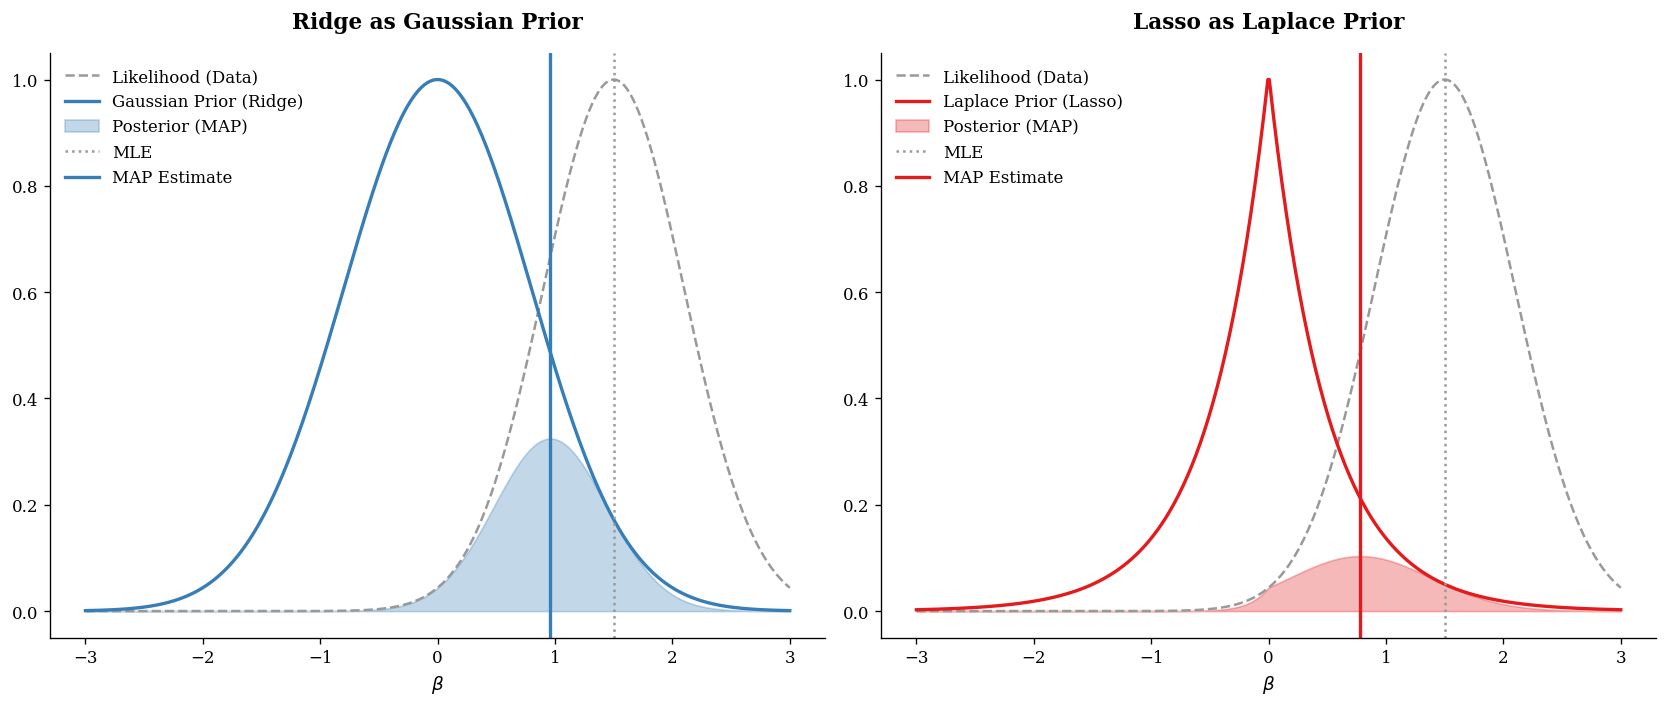

In [18]:
from scipy.stats import norm, laplace

# 1. 模拟似然函数 (Likelihood)
# 假设观测数据告诉我们 beta 应该在 1.5 附近
beta_range = np.linspace(-3, 3, 500)
mle_val = 1.5
std_dev = 0.6
likelihood = norm.pdf(beta_range, mle_val, std_dev)
likelihood /= likelihood.max() # 归一化方便展示

# 2. 定义先验 (Priors)
# Gaussian Prior (Ridge)
prior_gaussian = norm.pdf(beta_range, 0, 0.8)
prior_gaussian /= prior_gaussian.max()

# Laplace Prior (Lasso)
prior_laplace = laplace.pdf(beta_range, 0, 0.5)
prior_laplace /= prior_laplace.max()

# 3. 计算后验 (Posterior \propto Likelihood * Prior)
post_ridge = likelihood * prior_gaussian
post_lasso = likelihood * prior_laplace

# 绘图
fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=120)

# --- 左图：Ridge (Gaussian Prior) ---
ax = axes[0]
ax.plot(beta_range, likelihood, '--', color=ISL_GRAY, label='Likelihood (Data)')
ax.plot(beta_range, prior_gaussian, '-', color=ISL_BLUE, lw=2, label='Gaussian Prior (Ridge)')
ax.fill_between(beta_range, post_ridge, color=ISL_BLUE, alpha=0.3, label='Posterior (MAP)')
ax.axvline(mle_val, color=ISL_GRAY, linestyle=':', label='MLE')
ax.axvline(beta_range[np.argmax(post_ridge)], color=ISL_BLUE, linestyle='-', lw=2, label='MAP Estimate')

ax.set_title("Ridge as Gaussian Prior", pad=15)
ax.set_xlabel(r"$\beta$")
ax.legend(frameon=False)

# --- 右图：Lasso (Laplace Prior) ---
ax = axes[1]
ax.plot(beta_range, likelihood, '--', color=ISL_GRAY, label='Likelihood (Data)')
ax.plot(beta_range, prior_laplace, '-', color=ISL_RED, lw=2, label='Laplace Prior (Lasso)')
ax.fill_between(beta_range, post_lasso, color=ISL_RED, alpha=0.3, label='Posterior (MAP)')
ax.axvline(mle_val, color=ISL_GRAY, linestyle=':', label='MLE')
ax.axvline(beta_range[np.argmax(post_lasso)], color=ISL_RED, linestyle='-', lw=2, label='MAP Estimate')

ax.set_title("Lasso as Laplace Prior", pad=15)
ax.set_xlabel(r"$\beta$")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

## Ridge vs Lasso: A Deeper Comparison

At a practical level:

## Ridge

- shrinks all coefficients  
- **rarely sets coefficients exactly to zero**  
- works well when many variables have small effects  
- especially useful for correlated predictors  

### Lasso

- **shrinks coefficients and can set some to zero**  
- performs variable selection  
- often produces simpler models  
- may be unstable when predictors are strongly correlated  

### Elastic Net

- **balances the two**
- useful for high-dimensional settings  
- often better when predictors occur in correlated groups  

## A Small Python Demo

Below is a simple example using simulated data.

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.metrics import mean_squared_error

# Reproducibility
np.random.seed(42)

# Simulate correlated predictors
n = 200
p = 20

X = np.random.randn(n, p)
X[:, 1] = X[:, 0] + 0.2 * np.random.randn(n)   # correlated with X0
X[:, 2] = X[:, 0] - 0.2 * np.random.randn(n)   # correlated with X0

# True coefficients: only a few are important
beta_true = np.array([3.0, 2.0, 0.0, 0.0, -2.5] + [0.0]*(p-5))

# Response with noise
y = X @ beta_true + np.random.randn(n) * 2.0

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

# Standardize predictors
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# OLS
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)
y_pred_ols = ols.predict(X_test_scaled)

# Ridge
ridge = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

# Lasso
lasso = LassoCV(alphas=None, cv=5, max_iter=10000, random_state=42)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

# Elastic Net
enet = ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9], cv=5, max_iter=10000, random_state=42)
enet.fit(X_train_scaled, y_train)
y_pred_enet = enet.predict(X_test_scaled)

# Evaluate
results = pd.DataFrame({
    "Model": ["OLS", "Ridge", "Lasso", "Elastic Net"],
    "Test MSE": [
        mean_squared_error(y_test, y_pred_ols),
        mean_squared_error(y_test, y_pred_ridge),
        mean_squared_error(y_test, y_pred_lasso),
        mean_squared_error(y_test, y_pred_enet),
    ]
})

print(results)
print("\nChosen Ridge alpha:", ridge.alpha_)
print("Chosen Lasso alpha:", lasso.alpha_)
print("Chosen Elastic Net alpha:", enet.alpha_)
print("Chosen Elastic Net l1_ratio:", enet.l1_ratio_)

coef_df = pd.DataFrame({
    "Feature": [f"X{j}" for j in range(p)],
    "OLS": ols.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_,
    "Elastic Net": enet.coef_
})

print("\nCoefficients:")
print(coef_df.round(3))

         Model  Test MSE
0          OLS  4.878529
1        Ridge  4.954559
2        Lasso  4.750884
3  Elastic Net  4.875682

Chosen Ridge alpha: 5.72236765935022
Chosen Lasso alpha: 0.17561885593030502
Chosen Elastic Net alpha: 0.1012823360465176
Chosen Elastic Net l1_ratio: 0.7

Coefficients:
   Feature    OLS  Ridge  Lasso  Elastic Net
0       X0  2.252  1.734  2.370        1.774
1       X1  1.771  1.724  1.643        1.710
2       X2  0.651  1.155  0.455        1.064
3       X3 -0.075 -0.071 -0.000       -0.013
4       X4 -2.609 -2.497 -2.348       -2.413
5       X5  0.076  0.066  0.000        0.000
6       X6  0.323  0.320  0.143        0.251
7       X7 -0.084 -0.070 -0.000       -0.000
8       X8 -0.137 -0.128 -0.033       -0.087
9       X9 -0.036 -0.037 -0.000       -0.000
10     X10 -0.041 -0.044 -0.000       -0.012
11     X11 -0.202 -0.207 -0.019       -0.129
12     X12 -0.152 -0.131 -0.000       -0.053
13     X13  0.159  0.119  0.000        0.048
14     X14 -0.191 -0.181 -0.0

d:\Anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:1682: FutureWarning: 'alphas=None' is deprecated and will be removed in 1.9, at which point the default value will be set to 100. Set 'alphas=100' to silence this warning.
  warnings.warn(


## How to Read the Demo

Several things are worth paying attention to.

## Correlated predictors

We intentionally created correlated predictors. This is a setting where ordinary least squares can become unstable.

### Sparse signal

Only a few predictors truly matter. This makes Lasso and Elastic Net especially interesting, because they may shrink irrelevant coefficients to zero.

### Expected behavior

Although results vary from run to run, you will often see something like this:

- OLS gives a reasonable fit but can have noisy coefficient estimates  
- Ridge shrinks all coefficients and stabilizes prediction  
- Lasso sets many coefficients exactly to zero  
- Elastic Net behaves somewhere in between  

### Interpretation

The "best" method depends on the data-generating process. There is no universally dominant regularizer. The choice reflects assumptions about the structure of the signal.

## Common Misunderstandings

**Misunderstanding 1: "Regularization just makes the model worse"**

Not exactly. It often makes training fit worse, but improves generalization.

**Misunderstanding 2: "Regularization means dropping variables"**

Only some methods, such as Lasso, perform variable selection. Ridge usually does not.

**Misunderstanding 3: "Bigger $\lambda$ is always better"**

No. Too much regularization can cause underfitting.

**Misunderstanding 4: "Regularization is only for linear regression"**

No. It is a broad principle used across machine learning.

## Practical Guidance

When should you think seriously about regularization?

You should strongly consider it when:

- you have **many predictors**  
- predictors are **correlated**  
- your model **overfits**  
- coefficients seem unstable  
- prediction on unseen data matters more than perfect training fit  

A rough guide:

- Use **Ridge** when most variables may contain some signal  
- Use **Lasso** when you want sparsity and interpretability  
- Use **Elastic Net** when you want both shrinkage and variable selection, especially with correlated predictors  

## Summary

Regularization is one of the most powerful and general ideas in statistical learning. Its purpose is to control model complexity so that the fitted model generalizes better to new data.

The central optimization form is:

$$
\min_{\theta} \ \mathrm{Loss}(\theta) + \lambda \Omega(\theta)
$$

The most important examples are:

- **Ridge regression:** $L_2$ penalty, shrinks coefficients smoothly  
- **Lasso regression:** $L_1$ penalty, encourages sparsity  
- **Elastic Net:** combines both  

Conceptually, regularization works through the **bias-variance tradeoff**: it allows a bit more bias in exchange for lower variance and often better test performance.

From a Bayesian perspective, regularization is even more elegant:

- Ridge corresponds to a **Gaussian prior**  
- Lasso corresponds to a **Laplace prior**  

So regularization can be understood not only as a computational tool, but also as a principled way to encode beliefs that overly large or overly complex parameter values are unlikely.

## Quick Recap

You should now be able to answer these questions:

1. Why can a model with lower training error still perform worse on test data?  
2. What role does $\lambda$ play in regularization?  
3. Why does Ridge usually keep all variables while Lasso can remove some?  
4. Why do we usually standardize predictors before regularization?  
5. How does a Gaussian prior lead to the Ridge penalty?  
6. How does a Laplace prior lead to the Lasso penalty?  

## Knowledge Quiz

**Q1: What is the main purpose of regularization?**

A. To reduce training error as much as possible  
B. To control model complexity and improve generalization  
C. To remove all predictors  
D. To guarantee unbiased estimates  
<details>
<summary>Answer</summary>
**B.** To control model complexity and improve generalization
</details>

---

**Q2: If $\lambda$ becomes extremely large, what is the likely result?**

A. The model becomes more flexible  
B. The coefficients become less constrained  
C. The model may underfit  
D. The intercept becomes dominant because it is penalized  
<details>
<summary>Answer</summary>
**C.** The model may underfit
</details>

---

**Q3: Which statement best describes Ridge regression?**

A. It always sets many coefficients to zero  
B. It shrinks coefficients toward zero but usually keeps them nonzero  
C. It ignores correlated predictors  
D. It is unrelated to Bayesian thinking  
<details>
<summary>Answer</summary>
**B.** It shrinks coefficients toward zero but usually keeps them nonzero
</details>

---

**Q4: Which prior corresponds to Lasso?**

A. Uniform prior  
B. Gaussian prior  
C. Laplace prior  
D. Beta prior  
<details>
<summary>Answer</summary>
**C.** Laplace prior
</details>